Week 12 · Day 3 — Decoder Block
Why this matters

The decoder block lets Transformers generate sequences.
It uses:

Masked self-attention (so a token can’t see the “future”), and

Encoder–decoder attention (so the decoder attends to the encoder’s output).

This architecture powers machine translation, summarization, and text generation.

Theory Essentials

Masked Self-Attention: hides future tokens → autoregressive decoding.

Encoder–Decoder Attention: decoder queries the encoder’s outputs (context).

Stacked Structure:

Input → [LayerNorm → Masked Self-Attention → Residual]

Output → [LayerNorm → Encoder–Decoder Attention → Residual]

Output → [LayerNorm → Feed-Forward → Residual]

Preserves the same [batch, seq_len, d_model] shape throughout.

### Role of the Decoder

* The **encoder**: reads the *input sequence* (e.g., a sentence in Spanish) and produces a set of contextualized vectors — one for each input token.
* The **decoder**: takes those vectors and **generates the output sequence** (e.g., the English translation), one token at a time.

---

### How the Decoder Works

Each decoder block has **three parts**:

1. **Masked Self-Attention**

   * The decoder looks at the tokens it has already generated (`I`, `like`, …)
   * The *mask* prevents it from peeking at future tokens (so it can’t “cheat”).
   * Example: if you’ve generated `"I like"`, the next token prediction can only depend on `"I like"`, not the future word `"pizza"`.

2. **Cross-Attention (encoder–decoder attention)**

   * Queries come from the decoder’s current hidden state.
   * Keys and values come from the encoder’s output.
   * This lets the decoder “look back” at the input sequence.
   * Example: while predicting `"like"`, the decoder attends strongly to the Spanish word `"gusta"` in the encoder output.

3. **Feed-Forward + Residuals + LayerNorm**

   * Same as the encoder: non-linear transformation per token to refine the representation.

---

### Encoder + Decoder Together (example: translating *“Me gusta la pizza” → “I like pizza”*)

1. **Encoder stage**

   * Input tokens = `["Me", "gusta", "la", "pizza"]`
   * Output = contextual embeddings (each word represented in relation to its neighbors).

2. **Decoder stage**

   * Step 1: Start token `<sos>` → decoder predicts `"I"`.
   * Step 2: Now input = `["<sos>", "I"]`.

     * Masked self-attention → only looks at `<sos>` and `"I"`.
     * Cross-attention → aligns with `"Me"`.
     * Output = `"like"`.
   * Step 3: Input = `["<sos>", "I", "like"]`.

     * Cross-attention → focuses on `"pizza"`.
     * Output = `"pizza"`.
   * Step 4: Decoder predicts `<eos>` (end of sentence).

---

👉 In short:

* **Encoder** builds a rich map of the input sequence.
* **Decoder** walks through this map, one step at a time, generating output tokens, using **self-attention** to stay consistent with what it already wrote and **cross-attention** to align with the input.



In [ ]:
# Setup
import torch, torch.nn as nn
torch.manual_seed(42)

class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.enc_dec_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x, enc_out, tgt_mask=None):
        # 1) Masked self-attention
        attn_out, _ = self.self_attn(x, x, x, attn_mask=tgt_mask)
        x = self.norm1(x + attn_out)

        # 2) Encoder–decoder attention
        attn_out, _ = self.enc_dec_attn(x, enc_out, enc_out)
        x = self.norm2(x + attn_out)

        # 3) Feed-forward
        ff_out = self.ff(x)
        x = self.norm3(x + ff_out)
        return x

# Example run
batch, seq_len, d_model = 2, 5, 16
num_heads, d_ff = 2, 64

x = torch.rand(batch, seq_len, d_model)       # target input embeddings
enc_out = torch.rand(batch, seq_len, d_model) # encoder outputs. Random for this example

# Causal mask: prevent attending to future tokens
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
mask = mask.masked_fill(mask==1, float("-inf"))

decoder = DecoderBlock(d_model, num_heads, d_ff)
out = decoder(x, enc_out, tgt_mask=mask)
print("Output shape:", out.shape)


Output shape: torch.Size([2, 5, 16])


1) Core (10–15 min)
Task: Run decoder block with and without the causal mask. Compare outputs.

In [2]:
out_masked = decoder(x, enc_out, tgt_mask=mask)
out_unmasked = decoder(x, enc_out, tgt_mask=None)
print("Masked:", out_masked[0,0,:5])
print("Unmasked:", out_unmasked[0,0,:5])


Masked: tensor([ 1.1089,  0.7540, -0.3630,  0.8612, -0.9243], grad_fn=<SliceBackward0>)
Unmasked: tensor([ 0.9452,  0.9423, -0.2514,  0.8015, -0.9395], grad_fn=<SliceBackward0>)


Masked decoder (causal mask ON):
Each position can only attend to itself and earlier tokens.
→ Simulates left-to-right generation.
→ Example: predicting token 3 only uses tokens [1, 2], not [4, 5,…].

Unmasked decoder (no mask):
Each position can attend to all tokens, even the ones “in the future.”
→ This breaks the autoregressive rule.
→ Example: predicting token 3 can “peek” at token 4, which is cheating.

2) Practice (10–15 min)
Task: Change seq_len from 5 → 10. Confirm the causal mask still works.

In [3]:
seq_len = 10
x = torch.rand(batch, seq_len, d_model)
enc_out = torch.rand(batch, seq_len, d_model)
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
mask = mask.masked_fill(mask==1, float("-inf"))
print("Mask shape:", mask.shape)
out = decoder(x, enc_out, tgt_mask=mask)
print("Output shape:", out.shape)


Mask shape: torch.Size([10, 10])
Output shape: torch.Size([2, 10, 16])


3) Stretch (optional, 10–15 min)
Task: Visualize the causal mask.

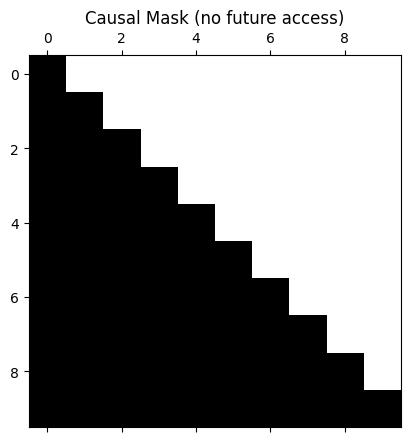

In [4]:
import matplotlib.pyplot as plt
plt.matshow(mask.numpy(), cmap="gray")
plt.title("Causal Mask (no future access)")
plt.show()


Mini-Challenge (≤40 min)

Build a Tiny Encoder–Decoder Pass.

Encoder: 1 block (from yesterday).

Decoder: 1 block (today).

Input: random sequence embeddings.

Output: decoded sequence.

Acceptance Criteria:

Encoder and decoder connect correctly (decoder uses encoder output).

Shape preserved [batch, seq_len, d_model].

Causal mask applied in decoder self-attentio

In [5]:
class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), 
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
    
    def forward(self, x):
        # x: [batch, seq_len, d_model]
        attn_out, _ = self.attn(x, x, x)  
        x = self.norm1(x + attn_out)       # residual + norm
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)         # residual + norm
        return x
    
class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.enc_dec_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x, enc_out, tgt_mask=None):
        # 1) Masked self-attention
        attn_out, _ = self.self_attn(x, x, x, attn_mask=tgt_mask)
        x = self.norm1(x + attn_out)

        # 2) Encoder–decoder attention
        attn_out, _ = self.enc_dec_attn(x, enc_out, enc_out)
        x = self.norm2(x + attn_out)

        # 3) Feed-forward
        ff_out = self.ff(x)
        x = self.norm3(x + ff_out)
        return x


# Example run
seq_len, d_model, num_heads, d_ff = 10, 16, 2, 64 # dff is the feed-forward hidden size
x = torch.rand(2, seq_len, d_model)  # batch=2
encoder_block = SelfAttentionBlock(d_model, num_heads, d_ff)
enc_out = encoder_block(x)

mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
mask = mask.masked_fill(mask==1, float("-inf"))

decoder = DecoderBlock(d_model, num_heads, d_ff)
out = decoder(x, enc_out, tgt_mask=mask)
print("Input shape:", x.shape)
print("Output shape:", out.shape)

Input shape: torch.Size([2, 10, 16])
Output shape: torch.Size([2, 10, 16])


Notes / Key Takeaways

Decoder has two attention steps: self-attn (masked) + cross-attn (with encoder).

Mask ensures autoregressive generation.

Encoder–decoder attention injects contextual knowledge.

Residual + LayerNorm keep training stable.

Structure scales by stacking many blocks.

Output stays same dimension as input embeddings.

Reflection

Why does the decoder need both masked self-attention and encoder–decoder attention?

What would go wrong if we removed the causal mask?

1. Why does the decoder need both masked self-attention and encoder–decoder attention?

Masked self-attention: lets the decoder look only at already generated tokens → keeps generation left-to-right and consistent.

Encoder–decoder attention: lets the decoder align those generated tokens with the input sequence → ensures the output is grounded in the source (e.g., translation “gusta” → “like”).
Together: the decoder balances its own past context (self-attention) with the source information (cross-attention).

2. What would go wrong if we removed the causal mask?

The decoder could “cheat” by seeing future tokens during training.

That would make training loss artificially low, but at inference time (when future tokens aren’t available) the model would fail badly.

In other words: it would learn dependencies that aren’t possible in real left-to-right generation → outputs become inconsistent or collapse.

👉 Memory hook:

Masked self-attention = don’t peek ahead.

Encoder–decoder attention = look back at the source.